# NCAA March Mania 2026 — Integrated Model

**Base model:** XGBoost regression on point differential, box score averages, GLM quality, spline calibration.

**Enhancements integrated:**
1. Improved Elo engine — home court advantage, margin-of-victory multiplier, season regression
2. Rich Elo-derived features — elo_vs_peak, trends, strength of schedule, behavioral win rates
3. Massey ordinal ratings (POM, SAG, MOR, WLK) for men's teams
4. Elo-Massey divergence signal

## 1. Load Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings
import re

from scipy.stats import linregress

warnings.filterwarnings("ignore")
pd.set_option("display.max_column", 999)
data_dir = "data/"

M_regular_results = pd.read_csv(f"{data_dir}MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv(f"{data_dir}MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv(f"{data_dir}MNCAATourneySeeds.csv")

W_regular_results = pd.read_csv(f"{data_dir}WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv(f"{data_dir}WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv(f"{data_dir}WNCAATourneySeeds.csv")

# Massey ordinals (men only)
massey = pd.read_csv(f"{data_dir}MMasseyOrdinals.csv")

regular_results = pd.concat([M_regular_results, W_regular_results])
tourney_results = pd.concat([M_tourney_results, W_tourney_results])
seeds = pd.concat([M_seeds, W_seeds])

season = 2003
regular_results = regular_results.loc[regular_results["Season"] >= season]
tourney_results = tourney_results.loc[tourney_results["Season"] >= season]
seeds = seeds.loc[seeds["Season"] >= season]


Men regular season games: 124,529
Women regular season games: 87,187
Massey file rows: 5,865,001
Massey unique systems: 197


## 2. Prepare Data

Each game is entered twice — once with Team A as T1 and once with Team B as T1 — so the model sees both perspectives symmetrically.

In [ ]:
def prepare_data(df):
    df = df[["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT",
            "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
            "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]]

    adjot = (40 + 5 * df["NumOT"]) / 40
    adjcols = ["LScore", "WScore",
               "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
               "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
    for col in adjcols:
        df[col] = df[col] / adjot

    dfswap = df.copy()
    df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(df.columns)]
    dfswap.columns = [x.replace("L", "T1_").replace("W", "T2_") for x in list(dfswap.columns)]
    output = pd.concat([df, dfswap]).reset_index(drop=True)
    output["PointDiff"] = output["T1_Score"] - output["T2_Score"]
    output["win"] = (output["PointDiff"] > 0) * 1
    output["men_women"] = (output["T1_TeamID"].apply(lambda t: str(t).startswith("1"))) * 1
    return output

regular_data = prepare_data(regular_results)
tourney_data = prepare_data(tourney_results)

Regular data rows: 423,432
Tourney data rows: 4,820


## 3. Feature Engineering — Seeds

In [3]:
seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))

seeds_T1 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T2 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T1.columns = ["Season", "T1_TeamID", "T1_seed"]
seeds_T2.columns = ["Season", "T2_TeamID", "T2_seed"]

tourney_data = tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win", "men_women"]]
tourney_data = pd.merge(tourney_data, seeds_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, seeds_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["Seed_diff"] = tourney_data["T2_seed"] - tourney_data["T1_seed"]

## 4. Feature Engineering — Box Score Averages

In [ ]:
boxcols = [
    "T1_Score", "T1_FGM", "T1_FGA", "T1_FGM3", "T1_FGA3", "T1_FTM", "T1_FTA",
    "T1_OR", "T1_DR", "T1_Ast", "T1_TO", "T1_Stl", "T1_Blk", "T1_PF",
    "T2_Score", "T2_FGM", "T2_FGA", "T2_FGM3", "T2_FGA3", "T2_FTM", "T2_FTA",
    "T2_OR", "T2_DR", "T2_Ast", "T2_TO", "T2_Stl", "T2_Blk", "T2_PF",
    "PointDiff",
]

ss = regular_data.groupby(["Season", "T1_TeamID"])[boxcols].agg("mean").reset_index()

ss_T1 = ss.copy()
ss_T1.columns = ["T1_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T1.columns)]
ss_T1 = ss_T1.rename({"T1_avg_Season": "Season", "T1_avg_TeamID": "T1_TeamID"}, axis=1)
ss_T2 = ss.copy()
ss_T2.columns = ["T2_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T2.columns)]
ss_T2 = ss_T2.rename({"T2_avg_Season": "Season", "T2_avg_TeamID": "T2_TeamID"}, axis=1)

tourney_data = pd.merge(tourney_data, ss_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, ss_T2, on=["Season", "T2_TeamID"], how="left")

Box score features added: 29 per team


## 5. Feature Engineering — Enhanced Elo Rating System

Upgraded from the base model's simple Elo (K=100, no adjustments) to a richer system:
- **K=30** — less volatile, more stable ratings
- **Home court advantage** (+100 Elo points) — adjusts expected probability
- **Margin of victory multiplier** — `clip(1 + margin/15, 0.5, 3.0)` — winning by 25 means more than winning by 1
- **Season regression** — ratings pulled 25% toward baseline each new season (roster turnover)
- **Game-by-game log** — enables trajectory features (elo_vs_peak, trends, schedule quality)

**Leakage fix:** Elo is computed from regular season games only. Tournament games are NOT included in the rating updates used for features — otherwise `elo_last` would contain post-tournament information, leaking outcomes into the prediction target.

In [ ]:
ELO_INIT = 1500
ELO_K = 30
ELO_HCA = 100
ELO_REG = 0.75

def compute_elo_regular_only(regular_df):
    """Compute Elo ratings from regular season games only.
    Returns end-of-regular-season ratings dict and game log with pre-game Elos.
    Tournament games are excluded to prevent leakage."""
    elo = {}
    season_end = {}
    game_log = []

    all_games = regular_df.copy().sort_values(['Season', 'DayNum']).reset_index(drop=True)
    prev_season = None

    for _, row in all_games.iterrows():
        s = row['Season']
        w_id, l_id = row['WTeamID'], row['LTeamID']
        loc = row.get('WLoc', 'N')

        # Season boundary: store end-of-regular-season ratings, then regress toward mean
        if s != prev_season:
            if prev_season is not None:
                for tid, r in elo.items():
                    season_end[(prev_season, tid)] = r
                elo = {tid: ELO_REG * r + (1 - ELO_REG) * ELO_INIT
                       for tid, r in elo.items()}
            prev_season = s

        r_w = elo.get(w_id, ELO_INIT)
        r_l = elo.get(l_id, ELO_INIT)

        r_w_adj = r_w + (ELO_HCA if loc == 'H' else (-ELO_HCA if loc == 'A' else 0))
        exp_w = 1.0 / (1.0 + 10 ** ((r_l - r_w_adj) / 400.0))

        mov = np.clip(1 + (row['WScore'] - row['LScore']) / 15, 0.5, 3.0)

        game_log.append({
            'Season': s, 'DayNum': row['DayNum'],
            'WTeamID': w_id, 'LTeamID': l_id,
            'WScore': row['WScore'], 'LScore': row['LScore'],
            'WLoc': loc,
            'r_w_pre': r_w, 'r_l_pre': r_l, 'exp_w': exp_w,
            'margin': row['WScore'] - row['LScore']
        })

        elo[w_id] = r_w + ELO_K * mov * (1.0 - exp_w)
        elo[l_id] = r_l + ELO_K * mov * (0.0 - (1.0 - exp_w))

    # Store final season
    if prev_season:
        for tid, r in elo.items():
            season_end[(prev_season, tid)] = r

    return season_end, pd.DataFrame(game_log)


print('Running enhanced Elo engine (regular season only)...')
# Detailed results contain all compact columns — no need to load separate compact files
elo_end_m, log_m = compute_elo_regular_only(M_regular_results)
elo_end_w, log_w = compute_elo_regular_only(W_regular_results)
print(f'Done. Men: {len(log_m):,} games | Women: {len(log_w):,} games')

Running enhanced Elo engine (regular season only)...
Done. Men: 124,529 games | Women: 87,187 games


### Elo-derived features

From the game-by-game log we extract richer signals than just end-of-season rating:

| Feature | What it captures |
|---|---|
| `elo_last` | End-of-season rating — current strength |
| `elo_vs_peak` | How far from season high — are they peaking or fading? |
| `elo_trend` | Full-season rating slope — overall trajectory |
| `elo_late_trend` | Feb+ rating slope — late-season momentum |
| `strength_of_schedule` | Average pre-game opponent Elo |
| `quality_of_wins` | Average Elo of opponents beaten |
| `win_rate_as_fav` | Consistency when favored |
| `win_rate_as_dog` | Upset ability |
| `close_game_win_rate` | Composure in tight games (≤5 pts) |
| `neutral_win_rate` | Performance on neutral courts (tournament proxy) |

In [6]:
def build_elo_features(game_log, elo_end_dict):
    """Build rich per-team-season features from Elo game log.
    Game log already contains only regular season games (no tourney leakage)."""
    log = game_log.copy()
    records = []

    for s in sorted(log['Season'].unique()):
        sg = log[log['Season'] == s]
        teams = set(sg['WTeamID'].tolist() + sg['LTeamID'].tolist())

        for tid in teams:
            won = sg[sg['WTeamID'] == tid]
            lost = sg[sg['LTeamID'] == tid]
            n_wins, n_losses = len(won), len(lost)
            n_games = n_wins + n_losses
            if n_games == 0:
                continue

            # Elo trajectory
            elo_w = won[['DayNum', 'r_w_pre']].rename(columns={'r_w_pre': 'elo'})
            elo_l = lost[['DayNum', 'r_l_pre']].rename(columns={'r_l_pre': 'elo'})
            te = pd.concat([elo_w, elo_l]).sort_values('DayNum')
            ev = te['elo'].values

            elo_last = elo_end_dict.get((s, tid), ELO_INIT)
            elo_mean = ev.mean()
            elo_std = ev.std() if len(ev) > 1 else 0
            elo_vs_peak = elo_last - ev.max()

            late = te[te['DayNum'] > 100]
            elo_late_trend = (linregress(range(len(late)), late['elo'].values)[0]
                              if len(late) >= 3 else 0)
            elo_trend = (linregress(range(len(ev)), ev)[0]
                         if len(ev) >= 3 else 0)

            # Schedule quality (pre-game opponent Elo to avoid leakage)
            all_opp = np.concatenate([won['r_l_pre'].values, lost['r_w_pre'].values])
            sos = all_opp.mean() if len(all_opp) > 0 else ELO_INIT
            qow = won['r_l_pre'].mean() if n_wins > 0 else ELO_INIT

            # Behavioral rates
            fav_wins = (won['r_w_pre'] > won['r_l_pre']).sum()
            dog_wins = (won['r_w_pre'] < won['r_l_pre']).sum()
            fav_games = fav_wins + (lost['r_l_pre'] > lost['r_w_pre']).sum()
            dog_games = dog_wins + (lost['r_l_pre'] < lost['r_w_pre']).sum()
            wraf = fav_wins / fav_games if fav_games > 0 else 0.5
            wrad = dog_wins / dog_games if dog_games > 0 else 0.0

            c_won = (won['margin'].abs() <= 5).sum()
            c_lost = (lost['margin'].abs() <= 5).sum()
            cgwr = c_won / (c_won + c_lost) if (c_won + c_lost) > 0 else 0.5

            n_won = won[won['WLoc'] == 'N']
            n_lost = lost[lost['WLoc'] == 'N']
            nn = len(n_won) + len(n_lost)
            nwr = len(n_won) / nn if nn > 0 else n_wins / n_games

            records.append({
                'Season': s, 'TeamID': tid,
                'elo_last': elo_last, 'elo_mean': elo_mean, 'elo_std': elo_std,
                'elo_trend': elo_trend, 'elo_late_trend': elo_late_trend,
                'elo_vs_peak': elo_vs_peak,
                'strength_of_schedule': sos, 'quality_of_wins': qow,
                'win_rate_as_fav': wraf, 'win_rate_as_dog': wrad,
                'close_game_win_rate': cgwr, 'neutral_win_rate': nwr,
            })

    return pd.DataFrame(records)


elo_feats_m = build_elo_features(log_m, elo_end_m)
elo_feats_w = build_elo_features(log_w, elo_end_w)
elo_features = pd.concat([elo_feats_m, elo_feats_w], ignore_index=True)

Elo feature table: 14,311 team-season rows, 12 features


In [7]:
elo_cols = [c for c in elo_features.columns if c not in ['Season', 'TeamID']]

elo_T1 = elo_features.copy()
elo_T1.columns = ['Season', 'T1_TeamID'] + [f'T1_{c}' for c in elo_cols]

elo_T2 = elo_features.copy()
elo_T2.columns = ['Season', 'T2_TeamID'] + [f'T2_{c}' for c in elo_cols]

tourney_data = pd.merge(tourney_data, elo_T1, on=['Season', 'T1_TeamID'], how='left')
tourney_data = pd.merge(tourney_data, elo_T2, on=['Season', 'T2_TeamID'], how='left')

# Compute diffs for key Elo features
tourney_data['elo_diff'] = tourney_data['T1_elo_last'] - tourney_data['T2_elo_last']
tourney_data['elo_vs_peak_diff'] = tourney_data['T1_elo_vs_peak'] - tourney_data['T2_elo_vs_peak']
tourney_data['elo_trend_diff'] = tourney_data['T1_elo_trend'] - tourney_data['T2_elo_trend']
tourney_data['elo_late_trend_diff'] = tourney_data['T1_elo_late_trend'] - tourney_data['T2_elo_late_trend']
tourney_data['sos_diff'] = tourney_data['T1_strength_of_schedule'] - tourney_data['T2_strength_of_schedule']
tourney_data['qow_diff'] = tourney_data['T1_quality_of_wins'] - tourney_data['T2_quality_of_wins']
tourney_data['neutral_wr_diff'] = tourney_data['T1_neutral_win_rate'] - tourney_data['T2_neutral_win_rate']
tourney_data['close_game_wr_diff'] = tourney_data['T1_close_game_win_rate'] - tourney_data['T2_close_game_win_rate']


## 6. Feature Engineering — Massey Ordinals

Expert ranking systems (POM, SAG, MOR, WLK) available for men's teams from 2003 onward. These capture efficiency-based and schedule-adjusted signals that Elo may miss.

In [8]:
SYSTEMS = ['POM', 'SAG', 'MOR', 'WLK']

massey_pre = (
    massey[massey['SystemName'].isin(SYSTEMS) & (massey['RankingDayNum'] <= 128)]
    .sort_values(['Season', 'TeamID', 'SystemName', 'RankingDayNum'])
    .groupby(['Season', 'TeamID', 'SystemName'])
    .last()
    .reset_index()
)

massey_pivot = massey_pre.pivot_table(
    index=['Season', 'TeamID'], columns='SystemName', values='OrdinalRank'
).reset_index()
massey_pivot.columns.name = None

massey_score_cols = []
for s in SYSTEMS:
    if s in massey_pivot.columns:
        col = f'massey_{s.lower()}'
        massey_pivot[col] = 400 - massey_pivot[s]
        massey_score_cols.append(col)
        massey_pivot.drop(columns=s, inplace=True)

massey_pivot['massey_consensus'] = massey_pivot[massey_score_cols].mean(axis=1)
massey_score_cols.append('massey_consensus')

# Merge for T1 and T2
massey_T1 = massey_pivot[['Season', 'TeamID'] + massey_score_cols].copy()
massey_T1.columns = ['Season', 'T1_TeamID'] + [f'T1_{c}' for c in massey_score_cols]

massey_T2 = massey_pivot[['Season', 'TeamID'] + massey_score_cols].copy()
massey_T2.columns = ['Season', 'T2_TeamID'] + [f'T2_{c}' for c in massey_score_cols]

tourney_data = pd.merge(tourney_data, massey_T1, on=['Season', 'T1_TeamID'], how='left')
tourney_data = pd.merge(tourney_data, massey_T2, on=['Season', 'T2_TeamID'], how='left')

tourney_data['massey_consensus_diff'] = tourney_data['T1_massey_consensus'] - tourney_data['T2_massey_consensus']

# Elo-Massey divergence: normalize within season, compute gap
# This signal captures teams whose Elo is inflated relative to expert assessment
for col_pair in [('T1_elo_last', 'T1_massey_consensus', 'T1_elo_massey_divergence'),
                 ('T2_elo_last', 'T2_massey_consensus', 'T2_elo_massey_divergence')]:
    elo_col, massey_col, div_col = col_pair
    elo_norm = tourney_data.groupby('Season')[elo_col].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0.5)
    massey_norm = tourney_data.groupby('Season')[massey_col].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0.5)
    tourney_data[div_col] = elo_norm - massey_norm

tourney_data['elo_massey_div_diff'] = (tourney_data['T1_elo_massey_divergence'].fillna(0) -
                                        tourney_data['T2_elo_massey_divergence'].fillna(0))

## 7. Feature Engineering — GLM Team Quality

GLM estimates team quality simultaneously from all games in a season using a linear model: `PointDiff ~ T1_TeamID + T2_TeamID`. This captures overall team strength adjusted for opponent quality in a single pass.

In [9]:
import statsmodels.api as sm
import tqdm

regular_data["ST1"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
regular_data["ST2"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)
seeds_T1["ST1"] = seeds_T1.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
seeds_T2["ST2"] = seeds_T2.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)

st = set(seeds_T1["ST1"]) | set(seeds_T2["ST2"])
st = st | set(regular_data.loc[(regular_data["T1_Score"] > regular_data["T2_Score"]) &
                               (regular_data["ST2"].isin(st)), "ST1"])

def team_quality(season, men_women):
    formula = "PointDiff~-1+T1_TeamID+T2_TeamID"
    glm = sm.GLM.from_formula(
        formula=formula,
        data=dt.loc[(dt["Season"] == season) & (dt["men_women"] == men_women), :],
        family=sm.families.Gaussian(),
    ).fit()
    quality = pd.DataFrame(glm.params).reset_index()
    quality.columns = ["TeamID", "quality"]
    quality["Season"] = season
    quality = quality.loc[quality.TeamID.str.contains("T1_")].reset_index(drop=True)
    quality["TeamID"] = quality["TeamID"].apply(lambda x: x[10:14]).astype(int)
    return quality

glm_quality = []
dt = regular_data.loc[regular_data["ST1"].isin(st) | regular_data["ST2"].isin(st)]
dt["T1_TeamID"] = dt["T1_TeamID"].astype(str)
dt["T2_TeamID"] = dt["T2_TeamID"].astype(str)
dt.loc[~dt["ST1"].isin(st), "T1_TeamID"] = "0000"
dt.loc[~dt["ST2"].isin(st), "T2_TeamID"] = "0000"
seasons = sorted(set(seeds["Season"]))
for s in tqdm.tqdm(seasons, unit="season"):
    if s >= 2010:
        glm_quality.append(team_quality(s, 0))
    if s >= 2003:
        glm_quality.append(team_quality(s, 1))
glm_quality = pd.concat(glm_quality)

glm_quality_T1 = glm_quality.copy().rename({"TeamID": "T1_TeamID", "quality": "T1_quality"}, axis=1)
glm_quality_T2 = glm_quality.copy().rename({"TeamID": "T2_TeamID", "quality": "T2_quality"}, axis=1)
tourney_data = pd.merge(tourney_data, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["diff_quality"] = tourney_data["T1_quality"] - tourney_data["T2_quality"]
print(f"GLM quality merged. Shape: {tourney_data.shape}")

100%|██████████| 23/23 [21:37<00:00, 56.43s/season]

GLM quality merged. Shape: (4820, 116)


## 8. Model — XGBoost

Predicts point differential (regression), then converts to win probability via spline calibration.

Features include the original modeh7 set plus enhanced Elo and Massey features.

In [10]:
features = [
    ### EASY FEATURES ###
    "men_women",
    "T1_seed",
    "T2_seed",
    "Seed_diff",
    ### MEDIUM FEATURES — BOX SCORE AVERAGES ###
    "T1_avg_Score",
    "T1_avg_FGA",
    "T1_avg_OR",
    "T1_avg_DR",
    "T1_avg_Blk",
    "T1_avg_PF",
    "T1_avg_opponent_FGA",
    "T1_avg_opponent_Blk",
    "T1_avg_opponent_PF",
    "T1_avg_PointDiff",
    "T2_avg_Score",
    "T2_avg_FGA",
    "T2_avg_OR",
    "T2_avg_DR",
    "T2_avg_Blk",
    "T2_avg_PF",
    "T2_avg_opponent_FGA",
    "T2_avg_opponent_Blk",
    "T2_avg_opponent_PF",
    "T2_avg_PointDiff",
    ### HARD FEATURES — ENHANCED ELO ###
    "T1_elo_last",
    "T2_elo_last",
    "elo_diff",
    "T1_elo_vs_peak",
    "T2_elo_vs_peak",
    "elo_vs_peak_diff",
    "T1_elo_trend",
    "T2_elo_trend",
    "elo_trend_diff",
    "T1_elo_late_trend",
    "T2_elo_late_trend",
    "elo_late_trend_diff",
    "T1_strength_of_schedule",
    "T2_strength_of_schedule",
    "sos_diff",
    "T1_quality_of_wins",
    "T2_quality_of_wins",
    "qow_diff",
    "T1_win_rate_as_fav",
    "T2_win_rate_as_fav",
    "T1_win_rate_as_dog",
    "T2_win_rate_as_dog",
    "T1_close_game_win_rate",
    "T2_close_game_win_rate",
    "close_game_wr_diff",
    "T1_neutral_win_rate",
    "T2_neutral_win_rate",
    "neutral_wr_diff",
    ### MASSEY FEATURES ###
    "T1_massey_consensus",
    "T2_massey_consensus",
    "massey_consensus_diff",
    "elo_massey_div_diff",
    ### HARDEST FEATURES — GLM ###
    "T1_quality",
    "T2_quality",
]

In [41]:
import optuna
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 100
TUNE_SEASONS = sorted(tourney_data["Season"].unique())[-10:]

def objective(trial):
    p = {
        "booster": "gbtree",
        "tree_method": "hist",
        "grow_policy": trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"]),
        "objective":   trial.suggest_categorical("objective", ["reg:squarederror", "reg:pseudohubererror"]),
        "eta":              trial.suggest_float("eta", 0.010, 0.035, log=True),
        "max_depth":        trial.suggest_int("max_depth", 2, 4),
        "subsample":        trial.suggest_float("subsample", 0.72, 1.0),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.50, 0.80),
        "min_child_weight": trial.suggest_int("min_child_weight", 2, 5),
        "max_bin":          trial.suggest_int("max_bin", 32, 64),
        "num_parallel_tree":trial.suggest_int("num_parallel_tree", 1, 3),
        "reg_alpha":        trial.suggest_float("reg_alpha", 0.05, 1.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0.005, 0.5, log=True),
    }
    n_rounds = trial.suggest_int("num_rounds", 500, 900)

    maes = []
    for oof_season in TUNE_SEASONS:
        x_tr = tourney_data.loc[tourney_data["Season"] != oof_season, features].values
        y_tr = tourney_data.loc[tourney_data["Season"] != oof_season, "PointDiff"].values
        x_va = tourney_data.loc[tourney_data["Season"] == oof_season, features].values
        y_va = tourney_data.loc[tourney_data["Season"] == oof_season, "PointDiff"].values
        m = xgb.train(p, xgb.DMatrix(x_tr, label=y_tr), num_boost_round=n_rounds, verbose_eval=False)
        maes.append(mean_absolute_error(y_va, m.predict(xgb.DMatrix(x_va))))
    return np.mean(maes)

study = optuna.create_study(direction="minimize")
study.enqueue_trial({
    "eta": 0.020082, "max_depth": 3, "subsample": 0.8721,
    "colsample_bynode": 0.6423, "min_child_weight": 3, "max_bin": 48,
    "num_parallel_tree": 2, "reg_alpha": 0.2023, "reg_lambda": 0.01696,
    "num_rounds": 660,
})
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best = study.best_params
print(f"\nBest MAE ({len(TUNE_SEASONS)} seasons): {study.best_value:.4f}")
print("Best params:", best)

param = best
num_rounds = best["num_rounds"]

  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 9.53268: 100%|██████████| 100/100 [12:55<00:00,  7.76s/it]


Best MAE (10 seasons): 9.5327
Best params: {'grow_policy': 'depthwise', 'objective': 'reg:pseudohubererror', 'eta': 0.020082, 'max_depth': 3, 'subsample': 0.8721, 'colsample_bynode': 0.6423, 'min_child_weight': 3, 'max_bin': 48, 'num_parallel_tree': 2, 'reg_alpha': 0.2023, 'reg_lambda': 0.01696, 'num_rounds': 660}


In [42]:
# param and num_rounds are set by the Optuna tuning cell above.
# If you skip tuning, uncomment the fallback below:

# param = {
#     "objective": "reg:squarederror", "booster": "gbtree",
#     "eta": 0.0093, "subsample": 0.6, "colsample_bynode": 0.8,
#     "num_parallel_tree": 2, "min_child_weight": 4, "max_depth": 4,
#     "tree_method": "hist", "grow_policy": "lossguide", "max_bin": 38,
# }
# num_rounds = 704

### Leave-One-Season-Out Validation

In [45]:
from sklearn.metrics import mean_absolute_error, brier_score_loss

models = {}
oof_mae = []
oof_preds = []
oof_targets = []
oof_ss = []

for oof_season in sorted(set(tourney_data.Season)):
    x_train = tourney_data.loc[tourney_data["Season"] != oof_season, features].values
    y_train = tourney_data.loc[tourney_data["Season"] != oof_season, "PointDiff"].values
    x_val = tourney_data.loc[tourney_data["Season"] == oof_season, features].values
    y_val = tourney_data.loc[tourney_data["Season"] == oof_season, "PointDiff"].values
    s_val = tourney_data.loc[tourney_data["Season"] == oof_season, "Season"].values

    dtrain = xgb.DMatrix(x_train, label=y_train)
    dval = xgb.DMatrix(x_val, label=y_val)
    models[oof_season] = xgb.train(
        params=param,
        dtrain=dtrain,
        num_boost_round=num_rounds,
    )
    preds = models[oof_season].predict(dval)
    print(f"oof season {oof_season} mae: {mean_absolute_error(y_val, preds):.4f}")
    oof_mae.append(mean_absolute_error(y_val, preds))
    oof_preds += list(preds)
    oof_targets += list(y_val)
    oof_ss += list(s_val)

print(f"\naverage mae: {np.mean(oof_mae):.4f}")

oof season 2003 mae: 8.8246
oof season 2004 mae: 8.0355
oof season 2005 mae: 7.9055
oof season 2006 mae: 8.5682
oof season 2007 mae: 7.8091
oof season 2008 mae: 9.2268
oof season 2009 mae: 9.1446
oof season 2010 mae: 9.1339
oof season 2011 mae: 9.4012
oof season 2012 mae: 7.9170
oof season 2013 mae: 10.1436
oof season 2014 mae: 9.9476
oof season 2015 mae: 7.9738
oof season 2016 mae: 9.5652
oof season 2017 mae: 9.4662
oof season 2018 mae: 9.9577
oof season 2019 mae: 9.6571
oof season 2021 mae: 10.1289
oof season 2022 mae: 10.0087
oof season 2023 mae: 9.5404
oof season 2024 mae: 9.2479
oof season 2025 mae: 9.7809

average mae: 9.1538


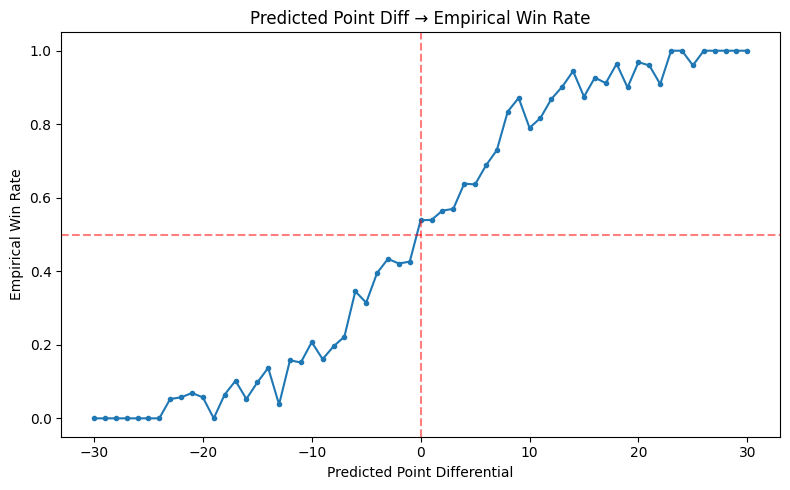

Seed AUC    : 0.1888
Model AUC   : 0.8354


In [46]:
from sklearn.metrics import roc_auc_score

df = pd.DataFrame(
    {"Season": oof_ss, "pred": oof_preds, "label": [(t > 0) * 1 for t in oof_targets], "men_women": tourney_data["men_women"].values}
)
df["pred_pointdiff"] = df["pred"].round()
xdf = df.clip(-30, 30).groupby("pred_pointdiff")[["label"]].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(xdf["pred_pointdiff"], xdf["label"], marker="o", markersize=3)
plt.xlabel("Predicted Point Differential")
plt.ylabel("Empirical Win Rate")
plt.title("Predicted Point Diff \u2192 Empirical Win Rate")
plt.axhline(0.5, color="red", linestyle="--", alpha=0.5)
plt.axvline(0, color="red", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Seed AUC    : {roc_auc_score(1 - tourney_data['win'], tourney_data['Seed_diff']):.4f}")
print(f"Model AUC   : {roc_auc_score(df['label'], df['pred']):.4f}")

## 9. Spline Calibration — Point Diff to Probability

Separate splines for men's and women's tournaments. Women's basketball has significantly wider point differentials (std=21.6 vs 14.6 for men), so a single spline compromises calibration for both.

Men Brier: 0.16972 (2898 games, clip=25)
Women Brier: 0.15785 (1922 games, clip=35)

Brier score (overall): 0.16499
  2003 Brier: 0.19166
  2004 Brier: 0.17949
  2005 Brier: 0.16839
  2006 Brier: 0.19216
  2007 Brier: 0.15391
  2008 Brier: 0.15101
  2009 Brier: 0.16783
  2010 Brier: 0.17169
  2011 Brier: 0.17973
  2012 Brier: 0.14312
  2013 Brier: 0.17759
  2014 Brier: 0.17329
  2015 Brier: 0.14162
  2016 Brier: 0.17282
  2017 Brier: 0.15691
  2018 Brier: 0.17423
  2019 Brier: 0.14480
  2021 Brier: 0.18011
  2022 Brier: 0.16747
  2023 Brier: 0.18900
  2024 Brier: 0.15588
  2025 Brier: 0.12320


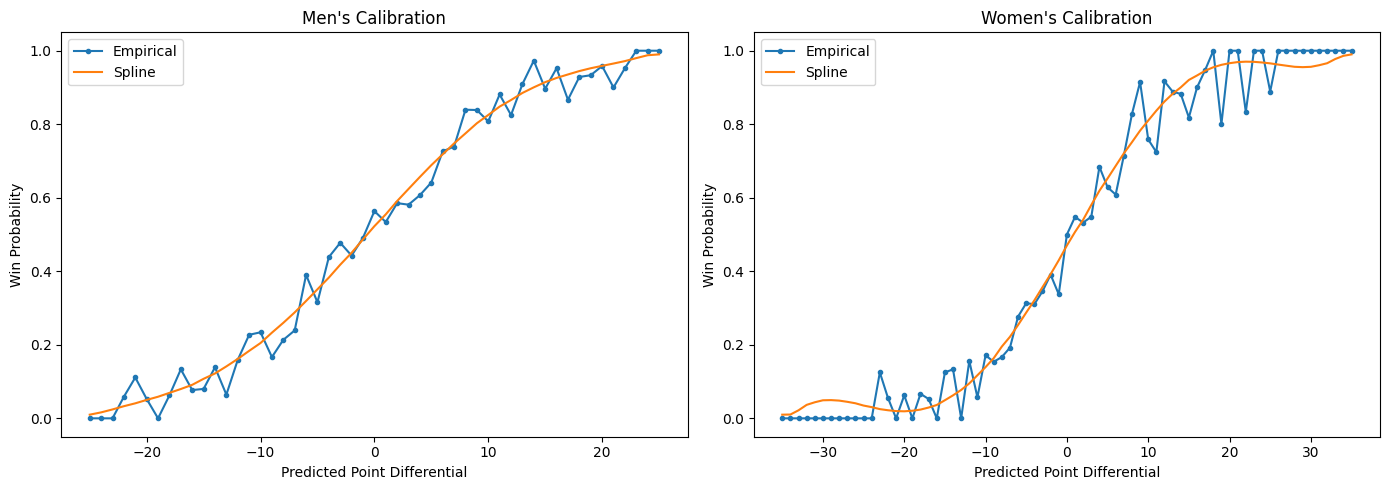

In [49]:
from scipy.interpolate import UnivariateSpline

oof_preds_arr = np.array(oof_preds)
oof_targets_arr = np.array(oof_targets)
oof_mw = tourney_data["men_women"].values

# Fit separate splines per gender
spline_models = {}
spline_clips = {}
spline_fit = np.zeros(len(oof_preds_arr))

for gender, label in [(1, "Men"), (0, "Women")]:
    mask = oof_mw == gender
    preds_g = oof_preds_arr[mask]
    targets_g = oof_targets_arr[mask]

    t_g = 25 if gender == 1 else 35
    spline_clips[gender] = t_g

    dat = sorted(zip(preds_g, targets_g > 0), key=lambda x: x[0])
    pred_sorted, label_sorted = zip(*dat)
    spline_models[gender] = UnivariateSpline(np.clip(pred_sorted, -t_g, t_g), label_sorted, k=5)

    fit_g = np.clip(spline_models[gender](np.clip(preds_g, -t_g, t_g)), 0.01, 0.99)
    spline_fit[mask] = fit_g

    bs = brier_score_loss(targets_g > 0, fit_g)
    print(f"{label} Brier: {bs:.5f} ({sum(mask)} games, clip={t_g})")

print(f"\nBrier score (overall): {brier_score_loss(oof_targets_arr > 0, spline_fit):.5f}")

for oof_season in sorted(set(tourney_data.Season)):
    mask = np.array(oof_ss) == oof_season
    if sum(mask) > 0:
        bs = brier_score_loss(oof_targets_arr[mask] > 0, spline_fit[mask])
        print(f"  {oof_season} Brier: {bs:.5f}")

# Plot calibration curves per gender
df["spline"] = spline_fit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (gender, label) in zip(axes, [(1, "Men"), (0, "Women")]):
    gdf = df[df["men_women"] == gender].copy()
    gdf["pred_pointdiff"] = gdf["pred"].round()
    t_g = spline_clips[gender]
    xdf = gdf.clip(-t_g, t_g).groupby("pred_pointdiff")[["spline", "label"]].mean().reset_index()
    ax.plot(xdf["pred_pointdiff"], xdf["label"], label="Empirical", marker="o", markersize=3)
    ax.plot(xdf["pred_pointdiff"], xdf["spline"], label="Spline")
    ax.set_xlabel("Predicted Point Differential")
    ax.set_ylabel("Win Probability")
    ax.set_title(f"{label}'s Calibration")
    ax.legend()
plt.tight_layout()
plt.show()

## 10. Feature Importance

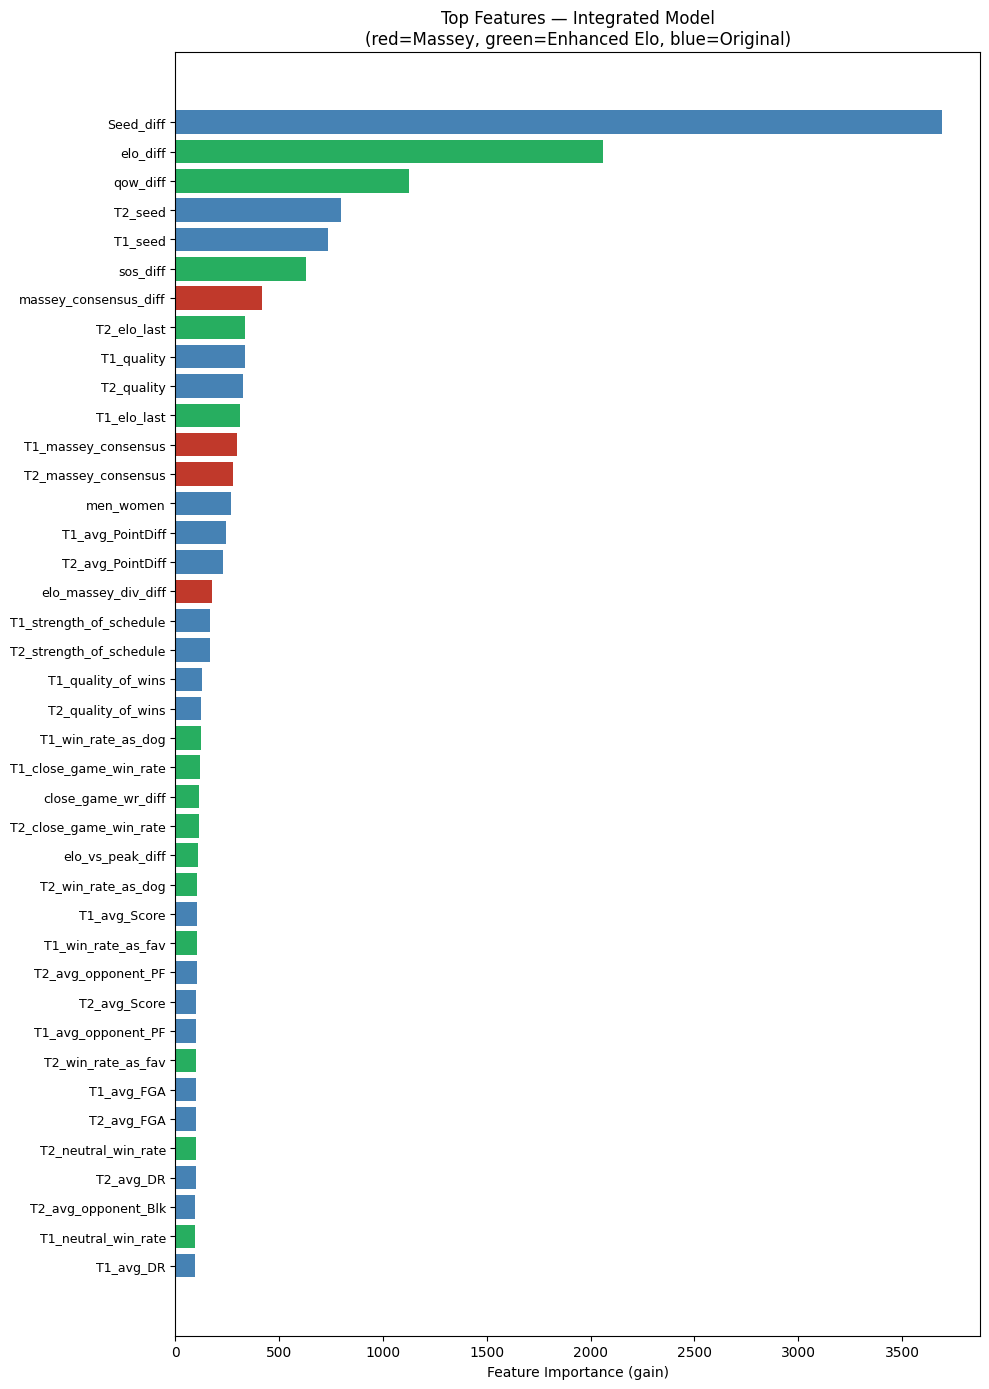

In [50]:
# Average feature importance across all LOSO models
imp_dict = {}
for season, model in models.items():
    scores = model.get_score(importance_type='gain')
    for i, feat_name in enumerate(features):
        key = f'f{i}'
        if key in scores:
            imp_dict.setdefault(feat_name, []).append(scores[key])

imp_df = pd.DataFrame([
    {'feature': k, 'importance': np.mean(v)} for k, v in imp_dict.items()
]).sort_values('importance', ascending=False)

colors = []
for f in imp_df['feature']:
    if 'massey' in f:
        colors.append('#c0392b')
    elif 'elo' in f or 'sos' in f or 'qow' in f or 'neutral_wr' in f or 'close_game' in f or 'win_rate' in f:
        colors.append('#27ae60')
    else:
        colors.append('steelblue')

plt.figure(figsize=(10, 14))
top_n = min(40, len(imp_df))
plt.barh(range(top_n), imp_df.head(top_n)['importance'].values[::-1], color=colors[:top_n][::-1])
plt.yticks(range(top_n), imp_df.head(top_n)['feature'].values[::-1], fontsize=9)
plt.xlabel('Feature Importance (gain)')
plt.title('Top Features \u2014 Integrated Model\n(red=Massey, green=Enhanced Elo, blue=Original)')
plt.tight_layout()
plt.show()

## 11. Generate Submission

In [51]:
X = pd.read_csv(f"{data_dir}SampleSubmissionStage2.csv")

X['Season'] = X['ID'].apply(lambda t: int(t.split('_')[0]))
X['T1_TeamID'] = X['ID'].apply(lambda t: int(t.split('_')[1]))
X['T2_TeamID'] = X['ID'].apply(lambda t: int(t.split('_')[2]))
X['men_women'] = X['T1_TeamID'].apply(lambda t: 1 if str(t)[0] == '1' else 0)

# Merge all feature sources
X = pd.merge(X, ss_T1, on=['Season', 'T1_TeamID'], how='left')
X = pd.merge(X, ss_T2, on=['Season', 'T2_TeamID'], how='left')
X = pd.merge(X, seeds_T1, on=['Season', 'T1_TeamID'], how='left')
X = pd.merge(X, seeds_T2, on=['Season', 'T2_TeamID'], how='left')
X = pd.merge(X, glm_quality_T1, on=['Season', 'T1_TeamID'], how='left')
X = pd.merge(X, glm_quality_T2, on=['Season', 'T2_TeamID'], how='left')
X = pd.merge(X, elo_T1, on=['Season', 'T1_TeamID'], how='left')
X = pd.merge(X, elo_T2, on=['Season', 'T2_TeamID'], how='left')
X = pd.merge(X, massey_T1, on=['Season', 'T1_TeamID'], how='left')
X = pd.merge(X, massey_T2, on=['Season', 'T2_TeamID'], how='left')

X["Seed_diff"] = X["T2_seed"] - X["T1_seed"]
X["elo_diff"] = X["T1_elo_last"] - X["T2_elo_last"]
X["elo_vs_peak_diff"] = X["T1_elo_vs_peak"] - X["T2_elo_vs_peak"]
X["elo_trend_diff"] = X["T1_elo_trend"] - X["T2_elo_trend"]
X["elo_late_trend_diff"] = X["T1_elo_late_trend"] - X["T2_elo_late_trend"]
X["sos_diff"] = X["T1_strength_of_schedule"] - X["T2_strength_of_schedule"]
X["qow_diff"] = X["T1_quality_of_wins"] - X["T2_quality_of_wins"]
X["neutral_wr_diff"] = X["T1_neutral_win_rate"] - X["T2_neutral_win_rate"]
X["close_game_wr_diff"] = X["T1_close_game_win_rate"] - X["T2_close_game_win_rate"]
X["massey_consensus_diff"] = X["T1_massey_consensus"] - X["T2_massey_consensus"]
X["diff_quality"] = X["T1_quality"] - X["T2_quality"]

# Elo-Massey divergence for submission
for col_pair in [('T1_elo_last', 'T1_massey_consensus', 'T1_elo_massey_divergence'),
                 ('T2_elo_last', 'T2_massey_consensus', 'T2_elo_massey_divergence')]:
    elo_col, massey_col, div_col = col_pair
    elo_norm = X.groupby('Season')[elo_col].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0.5)
    massey_norm = X.groupby('Season')[massey_col].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0.5)
    X[div_col] = elo_norm - massey_norm

X['elo_massey_div_diff'] = X['T1_elo_massey_divergence'].fillna(0) - X['T2_elo_massey_divergence'].fillna(0)

In [52]:
# Run all LOSO models and average predictions, using gender-specific splines
preds = []
for oof_season in set(tourney_data.Season):
    dtest = xgb.DMatrix(X[features].values)
    margin_preds = models[oof_season].predict(dtest)

    probs = np.zeros(len(margin_preds))
    for gender in [0, 1]:
        mask = X['men_women'].values == gender
        t_g = spline_clips[gender]
        probs[mask] = np.clip(
            spline_models[gender](np.clip(margin_preds[mask], -t_g, t_g)),
            0.01, 0.99
        )
    preds.append(probs)

X['Pred'] = np.array(preds).mean(axis=0)
X["Pred"] = X["Pred"].round(6)

X[['ID', 'Pred']].to_csv('predictions.csv', index=None)
print(X['Pred'].describe())

count    132133.000000
mean          0.684613
std           0.244121
min           0.010000
25%           0.528287
50%           0.739362
75%           0.890377
max           0.990000
Name: Pred, dtype: float64
